In [1]:
import math

import matplotlib.pyplot as plt

import torch
from torch import nn

import gamex_returns as gr        # data, figures and the animation live in that file

SEED = 20260908
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("cpu")  # force CPU for reproducibility

print("PyTorch:", torch.__version__)
print("Device:", device)

PyTorch: 2.7.1
Device: cpu


# GAMEX Practical 3 — A Continuous Transformer for Financial Returns

**Edinburgh Summer School on Generative AI for Extremes — 8 September 2026**
**Suggested time for this Notebook:** 25 minutes

The Transformer practical modelled arrival trajectories as sequences of discrete tokens.
This notebook keeps every value continuous: the model reads sixteen days of stock returns and outputs the **parameters of a density** for the next day. The data, the figures and the animation are in `gamex_returns.py`, imported above as `gr`.

## Learning goals

By the end you should be able to:

- explain why a continuous value needs a density head instead of a softmax;
- build a Transformer whose output at each position is $(\mu_t, \log\sigma_t)$;
- train it by Gaussian negative log-likelihood on real S&P 500 returns;
- read the fitted density day by day and compare it with a fixed Gaussian;
- generate future return paths autoregressively;
- continue a partially observed month, one density at a time;
- refit the same model with a Student-$t$ head on heavy-tailed data.

## 1. Load real S&P 500 returns

This notebook uses **real daily closes of the S&P 500** (1988–2026), cached in the repository so the practical stays offline.

We work with log returns in per cent,

$$
x_t = 100\,\log(\mathrm{price}_t / \mathrm{price}_{t-1}).
$$

The sign of $x_t$ is close to unpredictable. The size of the moves is not, since calm and violent years alternate.

In [2]:
dates, returns = gr.load_returns("data/indices.csv")   # closes -> log returns in per cent

print("Trading days:", len(returns))
print("First:", dates[0], "| Last:", dates[-1])
print("Std of daily returns:", f"{returns.std().item():.2f}%")
print("Worst day:", f"{returns.min().item():.1f}%", "| Best day:", f"{returns.max().item():.1f}%")

Trading days: 9009
First: 1988-01-05 | Last: 2026-08-24
Std of daily returns: 1.16%
Worst day: -12.8% | Best day: 10.4%


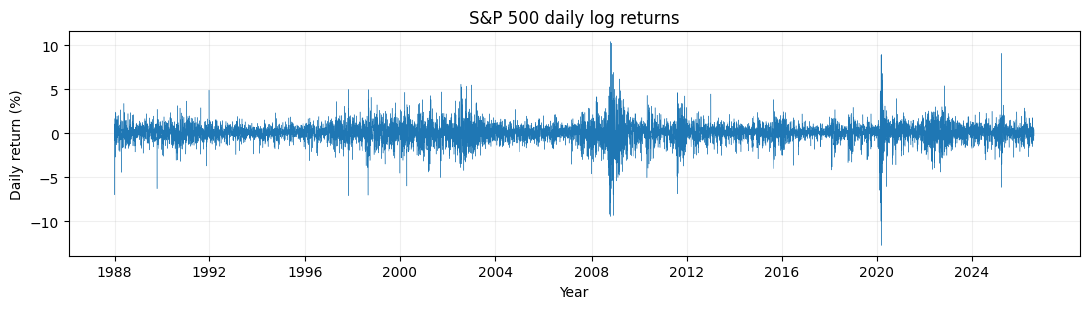

In [3]:
gr.plot_series(returns.numpy(), dates, "S&P 500 daily log returns")

## 2. Build autoregressive input/target windows

For a window of daily returns

$[x_1, x_2, \ldots, x_{17}]$,

the Transformer receives

$[x_1, x_2, \ldots, x_{16}]$

and predicts each next value. The model learns

$$
f(x_1,\ldots,x_{17}) = \prod^{17}_{t=2} f(x_t \mid x_{<t}),
$$

where each conditional is Gaussian with parameters computed by the network,

$$
x_t \mid x_{<t} \;\sim\; \mathrm{N}\{\mu_\theta(x_{<t}),\ \sigma_\theta(x_{<t})^2\}.
$$

The goal is a **distribution of plausible next days**, not a single forecast. The figure below shows one window: sixteen input days in blue, the target day in red, the surrounding days in grey.

In [4]:
BLOCK_SIZE = 16                                  # how many days the model reads before it speaks
BATCH_SIZE = 256

windows = returns.unfold(0, BLOCK_SIZE + 1, 1)   # every run of 17 consecutive days
inputs, targets = windows[:, :-1], windows[:, 1:]   # the same window shifted by one day

n_windows = len(windows)
permutation = torch.randperm(n_windows, generator=torch.Generator().manual_seed(SEED))
# neighbouring windows share 15 days, so a random split is a little optimistic
n_train = int(0.8 * n_windows)
n_val = int(0.1 * n_windows)
train_idx = permutation[:n_train]
val_idx = permutation[n_train:n_train + n_val]

train_loader = gr.make_loader(inputs[train_idx], targets[train_idx], BATCH_SIZE, SEED)

print("Windows:", n_windows)
print("Train/val/test:", n_train, "/", n_val, "/", n_windows - n_train - n_val)
print("Input shape:", tuple(inputs.shape), "| Target shape:", tuple(targets.shape))

Windows: 8993
Train/val/test: 7194 / 899 / 900
Input shape: (8993, 16) | Target shape: (8993, 16)


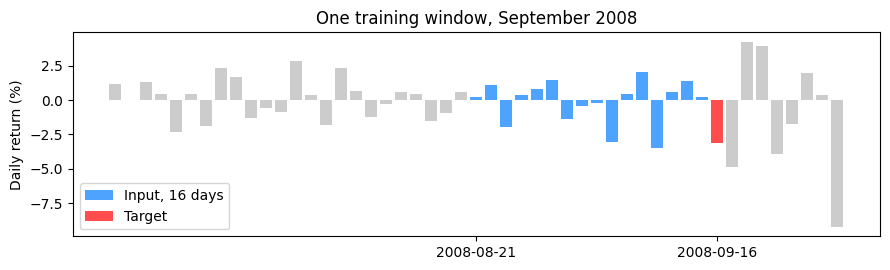

In [5]:
gr.plot_window(returns, dates, dates.index("2008-09-16"), BLOCK_SIZE)   # the week Lehman Brothers fell

## 3. Build a small continuous Transformer

The architecture is the arrival Transformer of Practical 1 with two changes.

- The token embedding table becomes a `Linear(1, d_model)`: the input is a number, not a category.
- The output head returns **two numbers per position**, $\mu_t$ and $\log\sigma_t$, instead of one score per vocabulary token. Working with $\log\sigma$ keeps $\sigma = e^{\log\sigma}$ positive with no constraint.

Everything in between — positional embedding, causal mask, encoder layers — is unchanged.

In [6]:
class GamexReturnsTransformer(nn.Module):
    def __init__(
        self,
        block_size=16,
        d_model=64,
        n_heads=4,
        n_layers=2,
        d_ff=64,
        dropout=0.1,
    ):
        super().__init__()
        self.config = {
            "block_size": block_size,
            "d_model": d_model,
            "n_heads": n_heads,
            "n_layers": n_layers,
            "d_ff": d_ff,
            "dropout": dropout,
        }
        self.input_projection = nn.Linear(1, d_model)        # one number in, not a row of a table
        self.position_embedding = nn.Embedding(block_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers, enable_nested_tensor=False)
        self.final_norm = nn.LayerNorm(d_model)
        self.density_head = nn.Linear(d_model, 2)            # two numbers out: a centre and a width

    def forward(self, x):
        n_steps = x.shape[1]
        positions = torch.arange(n_steps, device=x.device)
        hidden = self.input_projection(x.unsqueeze(-1)) + self.position_embedding(positions)
        causal = torch.triu(                                 # day t sees days up to t, never ahead
            torch.ones(n_steps, n_steps, dtype=torch.bool, device=x.device),
            diagonal=1,
        )
        hidden = self.final_norm(self.encoder(hidden, mask=causal))
        out = self.density_head(hidden)
        return out[..., 0], out[..., 1]   # mu and log sigma; the log keeps sigma positive

In [7]:
model = GamexReturnsTransformer().to(device)

with torch.inference_mode():
    probe_mu, probe_log_sigma = model(inputs[:4].to(device))

print("Parameters:", f"{sum(p.numel() for p in model.parameters()):,}")
print("mu shape:", tuple(probe_mu.shape), "| log sigma shape:", tuple(probe_log_sigma.shape))

Parameters: 51,842
mu shape: (4, 16) | log sigma shape: (4, 16)


## 4. Train via Gaussian negative log-likelihood

In Practical 1 the loss was cross-entropy, the negative log-likelihood of a categorical variable. Here the variable is continuous, so the loss is the negative log density of the observed next day,

$$
\mathcal{L}(\mathbf{\theta})
= \frac{1}{16}\sum^{17}_{t=2}
\left\{
\frac{(x_t-\mu_t)^2}{2\sigma_t^2} + \log\sigma_t + \tfrac{1}{2}\log 2\pi
\right\}.
$$

A large $|x_t - \mu_t|$ under a narrow $\sigma_t$ carries a heavy penalty, so minimising the loss makes $\sigma_t$ track the recent past.

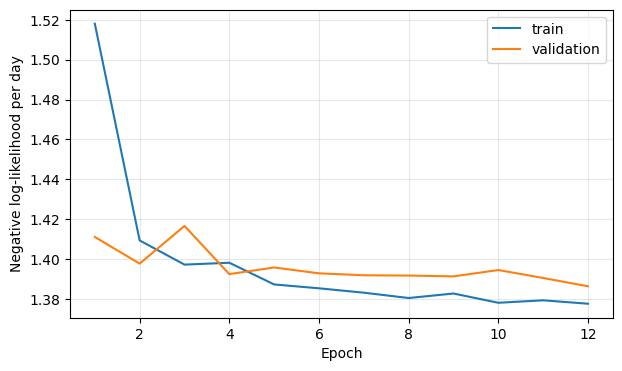

Epoch 12/12 | train loss 1.378 | val loss 1.386
Fixed Gaussian baseline: 1.573


In [8]:
def gaussian_nll(mu, log_sigma, target):
    z = (target - mu) * torch.exp(-log_sigma)   # the error, measured in its own sigmas
    # first term punishes a bad centre, second term punishes a lazy width
    return 0.5 * z ** 2 + log_sigma + 0.5 * math.log(2.0 * math.pi)


N_EPOCHS = 12                        # run this cell again for 12 more: the loop resumes

if "optimizer" not in globals():      # keep the optimiser and the history between runs
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
if "history" not in globals():
    history = {"train_nll": [], "val_nll": []}
start_epoch = len(history["train_nll"]) + 1

figure, axis = plt.subplots(figsize=(7, 4))

for epoch in range(start_epoch, start_epoch + N_EPOCHS):
    model.train()
    running_nll = 0.0
    for batch_inputs, batch_targets in train_loader:
        batch_inputs = batch_inputs.to(device)
        batch_targets = batch_targets.to(device)
        batch_mu, batch_log_sigma = model(batch_inputs)          # forward pass
        batch_loss = gaussian_nll(batch_mu, batch_log_sigma, batch_targets).mean()
        optimizer.zero_grad()                                    # resetting gradients
        batch_loss.backward()                                    # backward pass
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()                                         # update parameters
        running_nll += batch_loss.item() * len(batch_inputs)
    train_nll = running_nll / n_train

    model.eval()
    with torch.inference_mode():
        val_mu, val_log_sigma = model(inputs[val_idx].to(device))
        val_nll = gaussian_nll(val_mu, val_log_sigma, targets[val_idx].to(device)).mean().item()

    history["train_nll"].append(train_nll)
    history["val_nll"].append(val_nll)
    gr.live_loss_plot(figure, axis, history)
    print(f"Epoch {epoch:02d}/{start_epoch + N_EPOCHS - 1} | "
          f"train loss {train_nll:.3f} | val loss {val_nll:.3f}")
plt.close(figure)

# one fixed Gaussian for the whole history: the score to beat
flat_sd = returns[torch.sort(train_idx).values].std().item()
flat_nll = 0.5 * math.log(2.0 * math.pi * flat_sd ** 2) + 0.5
print("Fixed Gaussian baseline:", f"{flat_nll:.3f}")

### YOUR TURN 1 — How long should we train?
---

Try executing the training cell again.

What happens on the training and validation loss curves?

Consider which of the two decides when to stop, and what the gap between them measures.

## 5. The fitted density, day by day

Prediction is one forward pass. Sixteen days go in, $(\mu, \sigma)$ comes out.

We run the trained model over 2006–2010 and draw the band $\mu \pm 2\sigma$ over the observed returns. The band should be narrow through 2006, wide through 2008, and narrow again afterwards.

Over these years the model's average loss should sit further below the fixed-Gaussian baseline than it does on the full sample.

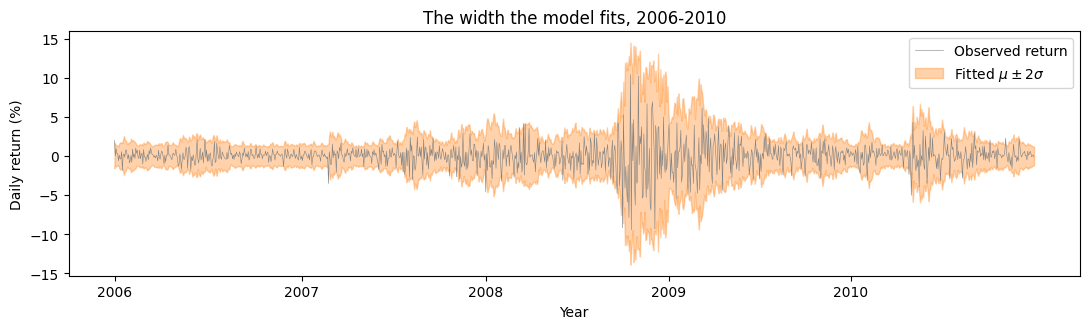

Average NLL 2006-2010 | model: 1.548 | fixed Gaussian: 2.033


In [9]:
period_lo = dates.index("2006-01-04")
period_hi = dates.index("2010-12-30")

model.eval()
with torch.inference_mode():
    all_mu, all_log_sigma = model(inputs.to(device))
next_mu = all_mu[:, -1].cpu()                    # last position of a window = the day after it
next_sigma = torch.exp(all_log_sigma[:, -1]).cpu()
next_day = torch.arange(BLOCK_SIZE, BLOCK_SIZE + n_windows)   # index of that day in `returns`

in_period = (next_day >= period_lo) & (next_day <= period_hi)
day = next_day[in_period].numpy()
mu_p = next_mu[in_period].numpy()
sigma_p = next_sigma[in_period].numpy()
observed = returns[next_day[in_period]].numpy()

gr.plot_band(day, observed, mu_p, sigma_p, dates, "The width the model fits, 2006-2010")

model_nll = gaussian_nll(torch.tensor(mu_p), torch.tensor(sigma_p).log(), torch.tensor(observed)).mean()
flat_nll_period = gaussian_nll(torch.tensor(0.0), torch.tensor(flat_sd).log(), torch.tensor(observed)).mean()
print("Average NLL 2006-2010 | model:", f"{model_nll:.3f}", "| fixed Gaussian:", f"{flat_nll_period:.3f}")

## 6. Generate future return paths

Sampling is: read the last sixteen days

→ one forward pass gives $(\mu, \sigma)$ for tomorrow

→ draw $x \sim \mathrm{N}(\mu, \sigma^2)$

→ append the draw and repeat.

We start the sampler at a calm day of 2017 and at 16 March 2020, the worst day of the COVID crash. The paths should start several times wider from the crash. The model is judged by its **distribution of paths**.

2017-07-31 | spread of day 1: 0.47% | day 25: 1.22%
2020-03-16 | spread of day 1: 4.19% | day 25: 6.49%


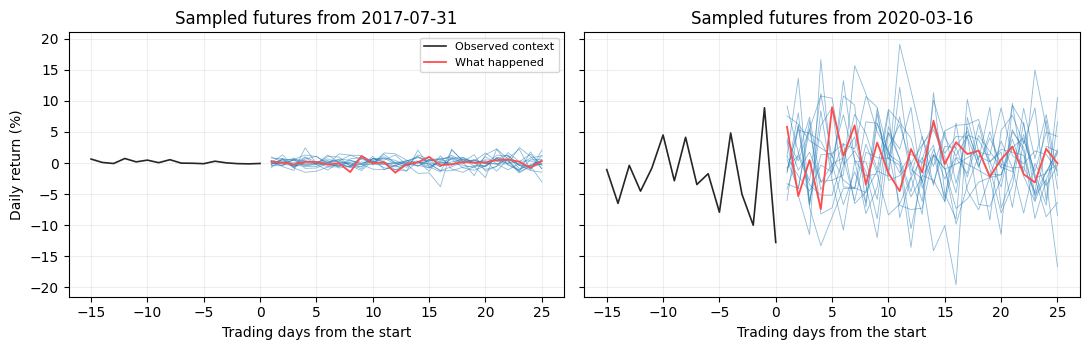

In [10]:
def sample_futures(start_date, horizon=25, n_paths=15, seed=SEED):
    g = torch.Generator().manual_seed(seed)
    start = dates.index(start_date)
    past = returns[start - BLOCK_SIZE + 1:start + 1].repeat(n_paths, 1)
    steps = []
    model.eval()
    with torch.inference_mode():
        for _ in range(horizon):
            mu, log_sigma = model(past[:, -BLOCK_SIZE:].to(device))   # only the last 16 days matter
            draw = mu[:, -1].cpu() + torch.exp(log_sigma[:, -1]).cpu() * torch.randn(n_paths, generator=g)
            steps.append(draw)
            past = torch.cat([past, draw[:, None]], dim=1)             # the draw becomes history
    return torch.stack(steps, dim=1)


start_dates = ("2017-07-31", "2020-03-16")
sampled = [sample_futures(d) for d in start_dates]
for d, group in zip(start_dates, sampled):
    print(f"{d} | spread of day 1: {group[:, 0].std():.2f}% | day 25: {group[:, -1].std():.2f}%")

gr.plot_paths(
    sampled,
    [returns[dates.index(d) - BLOCK_SIZE + 1:dates.index(d) + 1] for d in start_dates],
    [returns[dates.index(d) + 1:dates.index(d) + 1 + sampled[0].shape[1]] for d in start_dates],
    [f"Sampled futures from {d}" for d in start_dates],
    BLOCK_SIZE,
)

### YOUR TURN 2 — Where else should the paths start?
---

Try replacing one of the two dates above with a date of your choice, for example `"2011-08-08"` or `"2015-08-24"`.

Does the spread match what you know about that moment in market history?

## 7. Continue a partially observed month

The animation below continues sixteen observed days of the COVID crash, one day at a time.

At every step the left panel shows the path so far, and the right panel shows the **conditional density the model outputs for the next day**, with the sampled value marked. The context is violent, so the density starts wide, and it moves with every sampled day.

In [11]:
ANIMATION_START = "2020-03-16"        # the context is a crash, so the density starts wide
N_GENERATED = 22

g = torch.Generator().manual_seed(3)
anim_start = dates.index(ANIMATION_START)
running = returns[anim_start - BLOCK_SIZE + 1:anim_start + 1].clone()[None, :]
step_mu, step_sigma, step_draw = [], [], []

model.eval()
with torch.inference_mode():
    for _ in range(N_GENERATED):
        mu, log_sigma = model(running[:, -BLOCK_SIZE:].to(device))
        m = float(mu[0, -1])
        s = float(torch.exp(log_sigma[0, -1]))
        draw = m + s * float(torch.randn(1, generator=g))
        step_mu.append(m)             # keep the parameters, not only the draw:
        step_sigma.append(s)          # the animation redraws the density at every step
        step_draw.append(draw)
        running = torch.cat([running, torch.tensor([[draw]])], dim=1)

print("Prepared", N_GENERATED, "generation steps from", ANIMATION_START)

Prepared 22 generation steps from 2020-03-16


In [12]:
gr.animate_continuation(
    returns[anim_start - BLOCK_SIZE + 1:anim_start + 1].numpy(),
    step_mu, step_sigma, step_draw, ANIMATION_START,
)

## 8. Activity — GamexCoin

The GAMEX exchange lists exactly one asset: **GamexCoin (GMX)**, an altcoin whose community describes its volatility as a feature.

| The coin | One year on the exchange |
| :---: | :---: |
| <img src="figures/gamexcoin_logo.png" alt="GamexCoin" width="280"> | <img src="figures/gamexcoin_banner.png" alt="GMX/USD" width="640"> |

GamexCoin returns are synthetic and generated by `gr.make_gamexcoin_returns` (the appendix gives its specification), so the activity stays offline. Daily moves of $\pm 10\%$ are routine and $\pm 30\%$ happens.

The activity below refits the same Transformer with a **Student-$t$ head**, whose polynomial tails carry moves of that size.

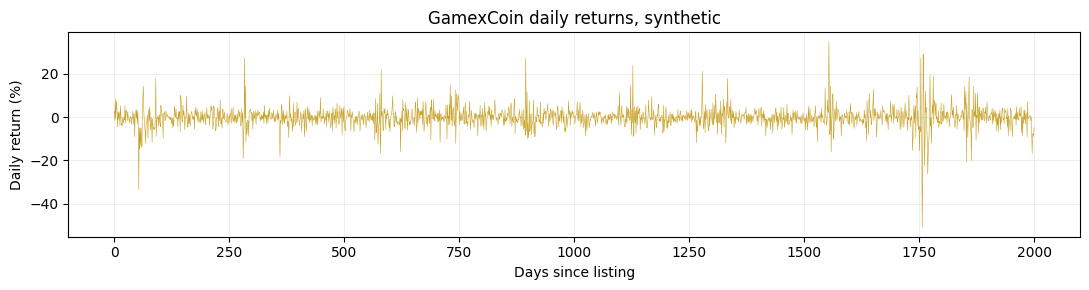

Std: 4.8% | Worst day: -51% | Days beyond +-15%: 31


In [13]:
gmx_returns = gr.make_gamexcoin_returns(n_days=2000, nu=4.0, seed=SEED)   # synthetic: no download

plt.figure(figsize=(11, 3))
plt.plot(gmx_returns.numpy(), linewidth=0.4, color="#c9a227")
plt.xlabel("Days since listing")
plt.ylabel("Daily return (%)")
plt.title("GamexCoin daily returns, synthetic")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("Std:", f"{gmx_returns.std():.1f}%", "| Worst day:", f"{gmx_returns.min():.0f}%",
      "| Days beyond +-15%:", int((gmx_returns.abs() > 15).sum()))

In [14]:
gmx_windows = gmx_returns.unfold(0, BLOCK_SIZE + 1, 1)
gmx_inputs, gmx_targets = gmx_windows[:, :-1], gmx_windows[:, 1:]
gmx_loader = gr.make_loader(gmx_inputs, gmx_targets, BATCH_SIZE, SEED)

# same class, same loop, same loss as above; only the data changed
gaussian_gmx = gr.train_on(GamexReturnsTransformer, gmx_loader, gaussian_nll, seed=SEED, device=device)
observed_4sigma, n_checked = gr.own_sigma_exceedances(gaussian_gmx, gmx_inputs, gmx_targets, device=device)
expected_4sigma = 2.0 * (1.0 - torch.special.ndtr(torch.tensor(4.0))).item() * n_checked   # 0.13 days

print("Days beyond 4 of the model's OWN sigmas | observed:", observed_4sigma,
      "of", n_checked, "| a Gaussian expects:", f"{expected_4sigma:.2f}")

Days beyond 4 of the model's OWN sigmas | observed: 8 of 1984 | a Gaussian expects: 0.13


The Gaussian model widens where it must, so raw counts of wild days look reasonable. It fails **conditionally**. Days beyond four of the model's own sigmas, expected about 0.1 times in a sample of this size, occurred many times.

The Student-$t$ head keeps $(\mu, \sigma)$ and adds tail thickness through $\nu$. With $z = (x - \mu)/\sigma$ (here $\sigma$ is the scale of the $t$, not its standard deviation), the negative log density is

$$
-\log f(x)
= \log\sigma
+ \tfrac{\nu+1}{2}\,\log\!\left(1 + z^2/\nu\right)
+ \log B_\nu,
\qquad
\log B_\nu = \tfrac{1}{2}\log(\nu\pi) + \log\Gamma(\tfrac{\nu}{2}) - \log\Gamma(\tfrac{\nu+1}{2}).
$$

Same network, same training loop; **only the loss changes**. Fill in the gaps below and run; the second print repeats the four-sigma check, whose expected count under a $t_\nu$ is estimated by Monte Carlo.

In [ ]:
# --- Activity, part 1: train the Student-t head on GamexCoin ---
# Fill in the degrees of freedom (small = heavy tails; the generator used 4.0)
# and the standardised value z. Training takes about ten seconds.

NU = ...                                  # e.g. 4.0


def student_t_nll(mu, log_sigma, target):
    z = ...                               # (target - mu) / sigma, using torch.exp(-log_sigma)
    log_B = 0.5 * math.log(NU * math.pi) + math.lgamma(NU / 2.0) - math.lgamma((NU + 1.0) / 2.0)
    return log_sigma + 0.5 * (NU + 1.0) * torch.log1p(z ** 2 / NU) + log_B


student_gmx = gr.train_on(GamexReturnsTransformer, gmx_loader, student_t_nll, seed=SEED, device=device)

with torch.inference_mode():
    mu_t, log_sigma_t = student_gmx(gmx_inputs.to(device))
    mu_g, log_sigma_g = gaussian_gmx(gmx_inputs.to(device))
nll_t = student_t_nll(mu_t, log_sigma_t, gmx_targets.to(device)).mean()
nll_g = gaussian_nll(mu_g, log_sigma_g, gmx_targets.to(device)).mean()
print("Average NLL on GamexCoin | Gaussian head:", f"{nll_g:.3f}", "| Student-t head:", f"{nll_t:.3f}")

observed_4sigma_t, _ = gr.own_sigma_exceedances(student_gmx, gmx_inputs, gmx_targets, device=device)
mc = torch.Generator().manual_seed(11)
chi2_mc = torch.randn(1_000_000, int(NU), generator=mc).square().sum(dim=1)
t_mc = torch.randn(1_000_000, generator=mc) * torch.sqrt(NU / chi2_mc)
expected_4sigma_t = float((t_mc.abs() > 4.0).float().mean()) * n_checked
print("Four-sigma check | Gaussian head:", observed_4sigma, "vs", f"{expected_4sigma:.2f}", "expected",
      "| Student-t head:", observed_4sigma_t, "vs", f"{expected_4sigma_t:.1f}", "expected")

### Would you buy GamexCoin?

The fitted head is a full conditional law, so it can be run forward from today by sampling tomorrow's return, feeding it back and sampling the day after. A return path becomes a price path through

$$
P_k = P_0 \exp\!\Big(\tfrac{1}{100}\sum_{j \le k} x_j\Big),
$$

the returns being log-returns in per cent. We set today's price to $100$, so the vertical axis reads directly as a percentage of what you would pay now.

GamexCoin fell hard in the days before today, and the model reads the last sixteen days, so the futures start from a wide density rather than a calm one.

The animation grows the futures one day at a time. The histogram on the right is the price on that day across all the generated futures, and the readout gives its median, the share of futures above today's price and the share that have halved.

In [ ]:
# --- Activity, part 2: would you buy GMX? ---
# Run the head you just fitted forward from today and read the prices it implies.
# Fill in the number of futures, the horizon and the sampler's t draw
# (sigma is the scale of the t, not its standard deviation: x = mu + sigma * T).

N_PATHS = ...                             # e.g. 300
HORIZON = ...                             # e.g. 30 trading days

g = torch.Generator().manual_seed(7)


def student_t_sampler(mu, sigma):
    chi2 = torch.randn(N_PATHS, int(NU), generator=g).square().sum(dim=1)
    t_draw = torch.randn(N_PATHS, generator=g) * torch.sqrt(NU / chi2)
    return ...                            # mu + sigma * t_draw


def gaussian_sampler(mu, sigma):
    return mu + sigma * torch.randn(N_PATHS, generator=g)


def generate_futures(net, sampler):
    past = gmx_returns[-BLOCK_SIZE:].repeat(N_PATHS, 1)      # today's window, one copy per future
    out = []
    net.eval()
    with torch.inference_mode():
        for _ in range(HORIZON):
            mu, log_sigma = net(past[:, -BLOCK_SIZE:].to(device))
            draw = sampler(mu[:, -1].cpu(), torch.exp(log_sigma[:, -1]).cpu())
            out.append(draw)                                 # the sampled day is fed back as context
            past = torch.cat([past, draw[:, None]], dim=1)
    return torch.stack(out, dim=1)


futures = generate_futures(student_gmx, student_t_sampler)
gr.animate_prices(gmx_returns[-120:], futures)

### YOUR TURN 3 — the same question under the Gaussian head

Re-run the cell above with `generate_futures(gaussian_gmx, gaussian_sampler)`. The two heads were fitted to the same coin and agree on $\mu$ and $\sigma$; they disagree only about how far a single day can go.

Does your decision change?

### Questions to discuss

- Would you buy GamexCoin, and at what horizon? Which number in the readout decided it?
- The two heads share $(\mu, \sigma)$ and differ only in the tail. Which diagnostics of this notebook can tell them apart, and which cannot?
- The S&P 500 also has heavier-than-Gaussian tails. What would change in Section 5 if the head there were a Student-$t$?
- GamexCoin is synthetic. What would you need to check before trusting either head on a real, thinly traded coin?

# Appendix: the GamexCoin generator

Returns follow a GARCH(1,1) with Student-$t$ innovations, in per cent,

$$
x_t = \sigma_t\,\varepsilon_t,
\qquad
\sigma_t^2 = \omega + a\,x_{t-1}^2 + b\,\sigma_{t-1}^2,
\qquad
\varepsilon_t \sim t_\nu / \sqrt{\nu/(\nu-2)},
$$

with $\omega = 1.2$, $a = 0.15$, $b = 0.80$ and $\nu = 4$, so the unconditional standard deviation is $\sqrt{\omega/(1-a-b)} \approx 4.9\%$ and fourth moments barely exist.

The $t_\nu$ draw is built from primitives so that it respects the seeded generator, $t_\nu = Z\,\sqrt{\nu / V}$ with $Z \sim \mathrm{N}(0,1)$ and $V \sim \chi^2_\nu$ from a sum of $\nu$ squared normals. The scaling by $\sqrt{\nu/(\nu-2)}$ makes $\operatorname{Var}(\varepsilon_t) = 1$, so $\sigma_t$ keeps its meaning as the conditional standard deviation under both heads.